In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) 读取 risk_rank_model
risk_path = r"E:\EY\EY_Project\risk_rank_model.csv"
risk = pd.read_csv(risk_path, dtype={"object_id": str})
print("risk:", risk.shape)

# 2) 读取 fact_object（如果你已经在 Notebook03 读过，可以跳过这段）
# 你需要从 fact_object 拉原始字段，才能做原因标签与图3
fact_path = r"E:\EY\EY_Project\fact_object.parquet"
fact = pd.read_parquet(fact_path)
fact["object_id"] = fact["object_id"].astype(str)
print("fact:", fact.shape)

# 3) 合并（以 risk 为主，保留排序字段）
df = risk.merge(fact, on="object_id", how="left", suffixes=("", "_fact"))
print("merged df:", df.shape)

risk: (726932, 20)
fact: (726932, 56)
merged df: (726932, 75)


In [3]:
TOP_N = 500   # 你可选 300/500
top = df.sort_values("global_rank").head(TOP_N).copy()
print("Top:", top.shape)

Top: (500, 75)


In [4]:
def to_num(s):
    return pd.to_numeric(s, errors="coerce")

def safe_div(a, b):
    a = to_num(a)
    b = to_num(b)
    return a / b.replace(0, np.nan)

In [17]:
# ======= 新增阈值（你可微调）=======
LONG_DAYS_TH = 365 * 3          # 3年
AMT_ABS_TH = 40000              # 4万（你也可以用分位数自动生成）
ZERO_CONSUME_LONG_TH = 365      # 1年
AMT_FOR_ZERO_CONSUME_TH = 10000  # 你可以改成分位数阈值

# 新原因列
top["DURATION_TOO_LONG"] = False
top["AMT_ABS_LARGE"] = False
top["ZERO_CONSUME_WITH_LONG"] = False



if ("当前消耗天数" in top.columns) and ("总天数" in top.columns) and ("可分摊金额" in top.columns):
    top["ZERO_CONSUME_WITH_LONG"] = (
        (to_num(top["当前消耗天数"]).fillna(0) == 0) &
        (to_num(top["总天数"]).fillna(0) > ZERO_CONSUME_LONG_TH) &
        (to_num(top["可分摊金额"]).abs().fillna(0) >= AMT_FOR_ZERO_CONSUME_TH)
    )


# 1) 服务期超长：总天数 or service_days
if "总天数" in top.columns:
    top["DURATION_TOO_LONG"] = to_num(top["总天数"]).fillna(0) > LONG_DAYS_TH
elif "service_days" in top.columns:
    top["DURATION_TOO_LONG"] = to_num(top["service_days"]).fillna(0) > LONG_DAYS_TH

# 2) 金额绝对值巨大（适配冲抵负数）
if "可分摊金额" in top.columns:
    top["AMT_ABS_LARGE"] = to_num(top["可分摊金额"]).abs().fillna(0) > AMT_ABS_TH

if ("当前消耗天数" in top.columns) and ("总天数" in top.columns) and ("可分摊金额" in top.columns):
    top["ZERO_CONSUME_WITH_LONG"] = (
        (to_num(top["当前消耗天数"]).fillna(0) == 0) &
        (to_num(top["总天数"]).fillna(0) > ZERO_CONSUME_LONG_TH) &
        (to_num(top["可分摊金额"]).abs().fillna(0) >= AMT_FOR_ZERO_CONSUME_TH)
    )

# 重新定义 reason_cols（原 5 + 新 3）
reason_cols2 = ["NEG_AMORT", "MONTH_SUM_MISMATCH", "GAP_HIGH", "EXP_SHIFT_LARGE", "SERVICE_OUTSIDE",
                "DURATION_TOO_LONG", "AMT_ABS_LARGE", "ZERO_CONSUME_WITH_LONG"]

# 重新生成 tags
top["reason_tags"] = top[reason_cols2].apply(
    lambda r: "|".join([c for c in reason_cols2 if bool(r[c])]) if any(r.values) else "NONE",
    axis=1
)

# 主原因：按优先级（先解释性强的）
priority = ["NEG_AMORT","MONTH_SUM_MISMATCH","EXP_SHIFT_LARGE","SERVICE_OUTSIDE","GAP_HIGH",
            "ZERO_CONSUME_WITH_LONG","DURATION_TOO_LONG","AMT_ABS_LARGE"]
priority = [c for c in priority if c in reason_cols2]

top["reason_primary"] = top[priority].apply(
    lambda r: next((c for c in priority if bool(r[c])), "NONE"),
    axis=1
)

display(top[["object_id","global_rank","risk_score","reason_primary","reason_tags"]].head(20))
print("Top50 reason_primary distribution:")
display(top.head(50)["reason_primary"].value_counts())

,object_id,global_rank,risk_score,reason_primary,reason_tags
0,664075,1,1.000000,EXP_SHIFT_LARGE,EXP_SHIFT_LARGE|DURATION_TOO_LONG
1,688886,2,0.999016,ZERO_CONSUME_WITH_LONG,DURATION_TOO_LONG|AMT_ABS_LARGE|ZERO_CONSUME_W...
2,035782,3,0.998903,NEG_AMORT,NEG_AMORT|EXP_SHIFT_LARGE|DURATION_TOO_LONG|ZE...
3,658085,4,0.998818,ZERO_CONSUME_WITH_LONG,DURATION_TOO_LONG|AMT_ABS_LARGE|ZERO_CONSUME_W...
4,038272,5,0.998411,NEG_AMORT,NEG_AMORT|EXP_SHIFT_LARGE|DURATION_TOO_LONG|ZE...
5,451629,6,0.998278,ZERO_CONSUME_WITH_LONG,AMT_ABS_LARGE|ZERO_CONSUME_WITH_LONG
6,495015,7,0.998278,ZERO_CONSUME_WITH_LONG,AMT_ABS_LARGE|ZERO_CONSUME_WITH_LONG
7,510813,8,0.998278,ZERO_CONSUME_WITH_LONG,AMT_ABS_LARGE|ZERO_CONSUME_WITH_LONG
8,591792,9,0.998278,ZERO_CONSUME_WITH_LONG,AMT_ABS_LARGE|ZERO_CONSUME_WITH_LONG
9,077983,10,0.998172,ZERO_CONSUME_WITH_LONG,ZERO_CONSUME_WITH_LONG


Top50 reason_primary distribution:


reason_primary
ZERO_CONSUME_WITH_LONG    42
EXP_SHIFT_LARGE            3
NEG_AMORT                  3
NONE                       2
Name: count, dtype: int64

In [18]:
check_cols = [
    "可分摊金额", "sum_month", "总月数", "nz_cnt", "span_month",
    "reschedule_days", "当前消耗天数", "总天数",
    "当前消耗金额", "当前剩余金额", "未分摊金额"
]
check_cols = [c for c in check_cols if c in top.columns]

tmp = top.head(50)[["object_id","global_rank","risk_score"] + check_cols].copy()
na_stat = tmp[check_cols].isna().mean().sort_values(ascending=False)

print("Top50 NA rate by column:")
display(na_stat)

display(tmp.head(15))

Top50 NA rate by column:


可分摊金额              0.0
sum_month          0.0
总月数                0.0
nz_cnt             0.0
span_month         0.0
reschedule_days    0.0
当前消耗天数             0.0
总天数                0.0
当前消耗金额             0.0
当前剩余金额             0.0
未分摊金额              0.0
dtype: float64

,object_id,global_rank,risk_score,可分摊金额,sum_month,总月数,nz_cnt,span_month,reschedule_days,当前消耗天数,总天数,当前消耗金额,当前剩余金额,未分摊金额
0,664075,1,1.000000,0.0,0.0,58,0,0,1391.913194,0,1727,0.0,-257.54,0.0
1,688886,2,0.999016,59997.0,59997.0,37,37,37,0.000000,0,1096,0.0,59997.00,0.0
2,035782,3,0.998903,-23997.0,-23997.0,73,73,73,1095.000000,0,2190,0.0,23997.00,0.0
3,658085,4,0.998818,59997.0,59997.0,37,37,37,0.000000,0,1096,0.0,59997.00,0.0
4,038272,5,0.998411,-23997.0,-23997.0,61,61,61,730.000000,0,1825,0.0,23997.00,0.0
5,451629,6,0.998278,59997.0,59997.0,36,36,36,0.000000,0,1095,0.0,59997.00,0.0
6,495015,7,0.998278,59997.0,59997.0,36,36,36,0.000000,0,1095,0.0,59997.00,0.0
7,510813,8,0.998278,59997.0,59997.0,36,36,36,0.000000,0,1095,0.0,59997.00,0.0
8,591792,9,0.998278,59997.0,59997.0,36,36,36,0.000000,0,1095,0.0,59997.00,0.0
9,077983,10,0.998172,38400.0,38400.0,36,36,36,0.000000,0,1095,0.0,38400.00,0.0


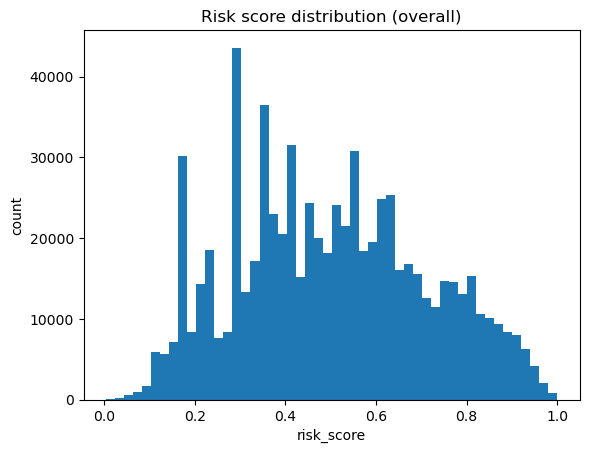

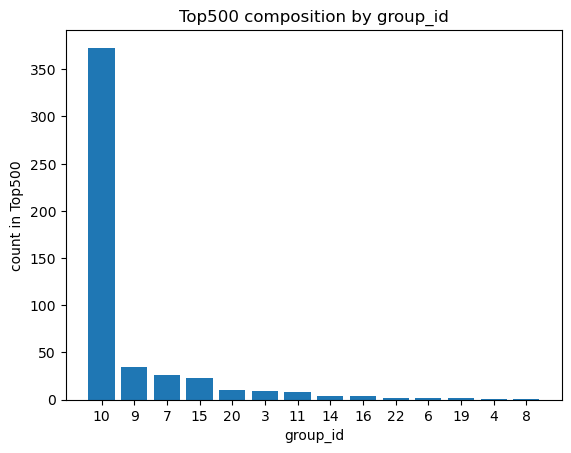

In [19]:
plt.figure()
plt.hist(df["risk_score"].dropna().values, bins=50)
plt.xlabel("risk_score")
plt.ylabel("count")
plt.title("Risk score distribution (overall)")
plt.show()

# 分组：TopN 中按 group_id 分布（更符合“overall + 分组”的第二部分）
vc = top["group_id"].value_counts().sort_values(ascending=False)
plt.figure()
plt.bar(vc.index.astype(str), vc.values)
plt.xlabel("group_id")
plt.ylabel(f"count in Top{TOP_N}")
plt.title(f"Top{TOP_N} composition by group_id")
plt.show()

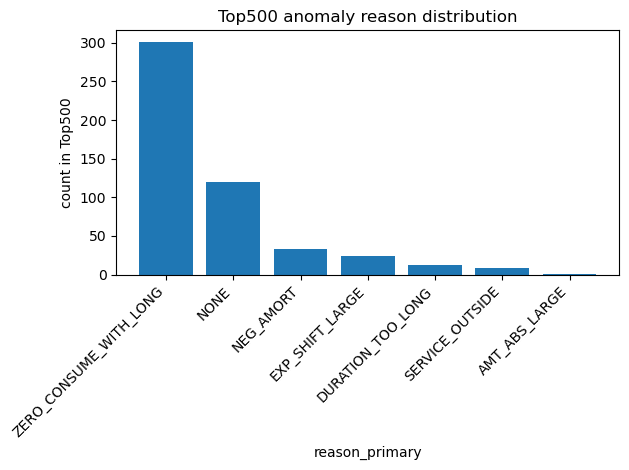

In [20]:
# 统计主原因分布（reason_primary）
vc2 = top["reason_primary"].value_counts().sort_values(ascending=False)

plt.figure()
plt.bar(vc2.index.astype(str), vc2.values)
plt.xlabel("reason_primary")
plt.ylabel(f"count in Top{TOP_N}")
plt.title(f"Top{TOP_N} anomaly reason distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

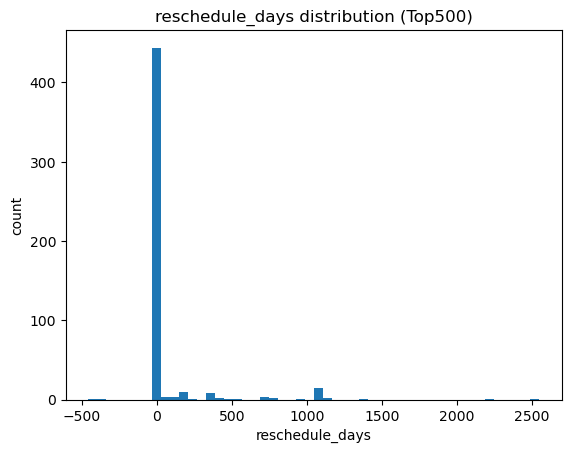

Top500 reschedule_days >= 90 days rate: 0.102


In [21]:
if "reschedule_days" not in df.columns:
    print("reschedule_days not found.")
else:
    # 只看 TopN，更能突出“极端改期”
    x = pd.to_numeric(top["reschedule_days"], errors="coerce").fillna(0).values

    plt.figure()
    plt.hist(x, bins=50)
    plt.xlabel("reschedule_days")
    plt.ylabel("count")
    plt.title(f"reschedule_days distribution (Top{TOP_N})")
    plt.show()

    # 再给一个“超过阈值”的比例（作为文字结论用）
    print(f"Top{TOP_N} reschedule_days >= {SHIFT_DAYS_TH} days rate:",
          float((x >= SHIFT_DAYS_TH).mean()))

In [22]:
import matplotlib
import matplotlib.pyplot as plt

# 常见可用中文字体候选（按优先级）
candidates = [
    "Microsoft YaHei", "SimHei", "SimSun", "Arial Unicode MS",
    "Noto Sans CJK SC", "Source Han Sans SC"
]

available = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
chosen = None
for f in candidates:
    if f in available:
        chosen = f
        break

print("Chosen font:", chosen)

if chosen:
    plt.rcParams["font.sans-serif"] = [chosen]
    plt.rcParams["axes.unicode_minus"] = False  # 解决负号显示问题
else:
    print("No CJK font found. Install a Chinese font (e.g., SimHei) or Noto Sans CJK.")

Chosen font: Microsoft YaHei


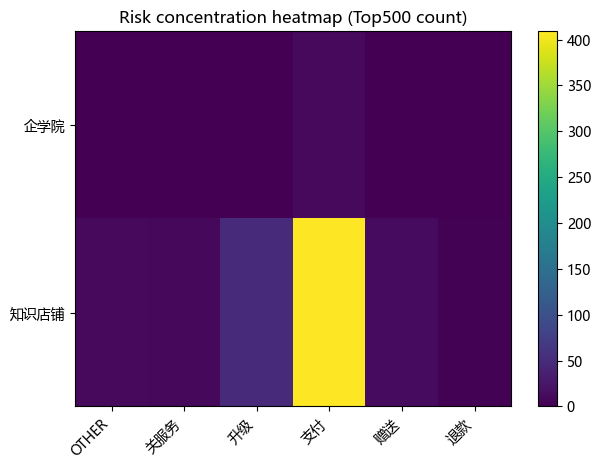

付款类型,OTHER,关服务,升级,支付,赠送,退款
业务类型,,,,,,
企学院,0,0,0,10,0,0
知识店铺,10,8,49,409,12,2


In [23]:
# 你表里列名是“业务类型”“付款类型”
if ("业务类型" not in top.columns) or ("付款类型" not in top.columns):
    print("Missing 业务类型/付款类型 for heatmap.")
else:
    pivot = pd.pivot_table(
        top,
        index="业务类型",
        columns="付款类型",
        values="object_id",
        aggfunc="count",
        fill_value=0
    )

    plt.figure()
    plt.imshow(pivot.values, aspect="auto")
    plt.xticks(range(pivot.shape[1]), pivot.columns.astype(str), rotation=45, ha="right")
    plt.yticks(range(pivot.shape[0]), pivot.index.astype(str))
    plt.colorbar()
    plt.title(f"Risk concentration heatmap (Top{TOP_N} count)")
    plt.tight_layout()
    plt.show()

    display(pivot)

In [13]:
# 1) 异常集中：TopN 组别
top_group = top["group_id"].value_counts().head(5)

# 2) 原因分布
top_reason = top["reason_primary"].value_counts().head(5)

# 3) 风险集中：业务类型×付款方式 Top cell
if ("业务类型" in top.columns) and ("付款类型" in top.columns):
    pivot = pd.pivot_table(top, index="业务类型", columns="付款类型", values="object_id",
                           aggfunc="count", fill_value=0)
    max_loc = np.unravel_index(np.argmax(pivot.values), pivot.shape)
    hot_business = pivot.index[max_loc[0]]
    hot_pay = pivot.columns[max_loc[1]]
    hot_cnt = int(pivot.values[max_loc])
else:
    hot_business, hot_pay, hot_cnt = "N/A", "N/A", 0

summary_lines = []
summary_lines.append(f"【Top{TOP_N} 风险对象结论摘要】")
summary_lines.append(f"1) 异常集中分组：Top5 group_id = {dict(top_group)}")
summary_lines.append(f"2) 主要异常模式：Top5 reason_primary = {dict(top_reason)}")
summary_lines.append(f"3) 风险集中热区：业务类型×付款方式 = ({hot_business}, {hot_pay})，Top{TOP_N} 内计数={hot_cnt}")
summary_lines.append("4) 复核建议：优先抽样 Top 风险对象中主因为 NEG_AMORT / MONTH_SUM_MISMATCH / EXP_SHIFT_LARGE 的样本，结合金额守恒、服务期一致性与改期流程进行定向核查。")

summary_text = "\n".join(summary_lines)
print(summary_text)

【Top500 风险对象结论摘要】
1) 异常集中分组：Top5 group_id = {10: 373, 9: 35, 7: 26, 15: 23, 20: 10}
2) 主要异常模式：Top5 reason_primary = {'ZERO_CONSUME_WITH_LONG': 356, 'NONE': 77, 'NEG_AMORT': 33, 'EXP_SHIFT_LARGE': 24, 'SERVICE_OUTSIDE': 9}
3) 风险集中热区：业务类型×付款方式 = (知识店铺, 支付)，Top500 内计数=409
4) 复核建议：优先抽样 Top 风险对象中主因为 NEG_AMORT / MONTH_SUM_MISMATCH / EXP_SHIFT_LARGE 的样本，结合金额守恒、服务期一致性与改期流程进行定向核查。
